In [5]:
!mkdir -p ~/.kaggle
!echo 'KGAT_2b7b64fdc8e6d009c0a0aed2cbf382cf' > ~/.kaggle/access_token
!chmod 600 ~/.kaggle/access_token
!pip install -q kaggle
!kaggle datasets download -d apollo2506/eurosat-dataset
!unzip -q eurosat-dataset.zip -d eurosat_data

Dataset URL: https://www.kaggle.com/datasets/apollo2506/eurosat-dataset
License(s): CC0-1.0
100% 2.04G/2.04G [00:15<00:00, 140MB/s]



In [6]:
!ls eurosat_data

EuroSAT  EuroSATallBands


In [7]:
!ls eurosat_data/*

eurosat_data/EuroSAT:
AnnualCrop	      Highway	      Pasture	     River     train.csv
Forest		      Industrial      PermanentCrop  SeaLake   validation.csv
HerbaceousVegetation  label_map.json  Residential    test.csv

eurosat_data/EuroSATallBands:
AnnualCrop	      Highway	      Pasture	     River     train.csv
Forest		      Industrial      PermanentCrop  SeaLake   validation.csv
HerbaceousVegetation  label_map.json  Residential    test.csv


In [8]:
!ls eurosat_data/EuroSAT/AnnualCrop | head -5

AnnualCrop_1000.jpg
AnnualCrop_1001.jpg
AnnualCrop_1002.jpg
AnnualCrop_1003.jpg
AnnualCrop_1004.jpg


In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [10]:
IMG_SIZE = 64  # keep small for speed; EuroSAT images are 64x64 natively anyway

# Baseline: no augmentation
transform_plain = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])
])

# With augmentation
transform_aug = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])
])

In [11]:
DATA_DIR = "eurosat_data/EuroSAT"

# Load once with plain transform just to get class info and do the split
full_dataset = datasets.ImageFolder(DATA_DIR, transform=transform_plain)

class_names = full_dataset.classes
print("Classes:", class_names)
print("Total images:", len(full_dataset))

# Split: 70% train, 15% val, 15% test
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

torch.manual_seed(42)
train_idx, val_idx, test_idx = random_split(full_dataset, [train_size, val_size, test_size])

print(f"Train: {len(train_idx)}, Val: {len(val_idx)}, Test: {len(test_idx)}")

Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Total images: 27000
Train: 18900, Val: 4050, Test: 4050


In [12]:
# Load the SAME dataset again, but with augmentation transform
full_dataset_aug = datasets.ImageFolder(DATA_DIR, transform=transform_aug)

# Reuse the exact same split indices (train_idx.indices etc.) but on the augmented dataset
from torch.utils.data import Subset

train_idx_list = train_idx.indices
val_idx_list = val_idx.indices
test_idx_list = test_idx.indices

# Plain (no augmentation) subsets
train_plain = Subset(full_dataset, train_idx_list)
val_plain   = Subset(full_dataset, val_idx_list)
test_plain  = Subset(full_dataset, test_idx_list)

# Augmented subsets (only train gets augmentation; val/test should stay clean for fair evaluation)
train_aug = Subset(full_dataset_aug, train_idx_list)
val_aug   = Subset(full_dataset, val_idx_list)   # keep val/test plain even in the "augmented" run
test_aug  = Subset(full_dataset, test_idx_list)

BATCH_SIZE = 64

loaders_plain = {
    "train": DataLoader(train_plain, batch_size=BATCH_SIZE, shuffle=True, num_workers=2),
    "val":   DataLoader(val_plain, batch_size=BATCH_SIZE, shuffle=False, num_workers=2),
    "test":  DataLoader(test_plain, batch_size=BATCH_SIZE, shuffle=False, num_workers=2),
}

loaders_aug = {
    "train": DataLoader(train_aug, batch_size=BATCH_SIZE, shuffle=True, num_workers=2),
    "val":   DataLoader(val_aug, batch_size=BATCH_SIZE, shuffle=False, num_workers=2),
    "test":  DataLoader(test_aug, batch_size=BATCH_SIZE, shuffle=False, num_workers=2),
}

print("DataLoaders ready.")

DataLoaders ready.


In [13]:
class TinyVGG(nn.Module):
    def __init__(self, num_classes=10):
        super(TinyVGG, self).__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)  # 64 -> 32
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)  # 32 -> 16
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)  # 16 -> 8
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return x

# Quick sanity check
model_test = TinyVGG(num_classes=10).to(device)
sample = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)
out = model_test(sample)
print("Output shape:", out.shape)  # should be [1, 10]

Output shape: torch.Size([1, 10])


In [14]:
def train_model(model, loaders, num_epochs=10, lr=0.001, model_name="model"):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(num_epochs):
        # ---- Training ----
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for inputs, labels in loaders["train"]:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        # ---- Validation ----
        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in loaders["val"]:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss = val_running_loss / val_total
        val_acc = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"[{model_name}] Epoch {epoch+1}/{num_epochs} | "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    return model, history


def evaluate_model(model, test_loader, class_names, model_name="model"):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    print(f"[{model_name}] Test Accuracy: {acc:.4f}")

    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(10, 10))
    disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()
    plt.savefig(f"confusion_matrix_{model_name}.png", dpi=150)
    plt.show()

    return acc, cm


def plot_curves(history, model_name="model"):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, history["train_loss"], label="Train Loss")
    axes[0].plot(epochs, history["val_loss"], label="Val Loss")
    axes[0].set_title(f"{model_name} - Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(epochs, history["train_acc"], label="Train Acc")
    axes[1].plot(epochs, history["val_acc"], label="Val Acc")
    axes[1].set_title(f"{model_name} - Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(f"curves_{model_name}.png", dpi=150)
    plt.show()

In [15]:
# ---- Run 1: TinyVGG, no augmentation ----
model_scratch_plain = TinyVGG(num_classes=10)
model_scratch_plain, hist_scratch_plain = train_model(
    model_scratch_plain, loaders_plain, num_epochs=10, lr=0.001,
    model_name="TinyVGG_NoAug"
)

[TinyVGG_NoAug] Epoch 1/10 | Train Loss: 1.1852, Train Acc: 0.5641 | Val Loss: 0.7503, Val Acc: 0.7343
[TinyVGG_NoAug] Epoch 2/10 | Train Loss: 0.6790, Train Acc: 0.7618 | Val Loss: 0.5526, Val Acc: 0.8037
[TinyVGG_NoAug] Epoch 3/10 | Train Loss: 0.5330, Train Acc: 0.8161 | Val Loss: 0.4551, Val Acc: 0.8331
[TinyVGG_NoAug] Epoch 4/10 | Train Loss: 0.4863, Train Acc: 0.8368 | Val Loss: 0.4037, Val Acc: 0.8699
[TinyVGG_NoAug] Epoch 5/10 | Train Loss: 0.3901, Train Acc: 0.8677 | Val Loss: 0.3297, Val Acc: 0.8928
[TinyVGG_NoAug] Epoch 6/10 | Train Loss: 0.3340, Train Acc: 0.8871 | Val Loss: 0.3387, Val Acc: 0.8864
[TinyVGG_NoAug] Epoch 7/10 | Train Loss: 0.2937, Train Acc: 0.9021 | Val Loss: 0.2760, Val Acc: 0.9047
[TinyVGG_NoAug] Epoch 8/10 | Train Loss: 0.2651, Train Acc: 0.9078 | Val Loss: 0.3048, Val Acc: 0.8953
[TinyVGG_NoAug] Epoch 9/10 | Train Loss: 0.2094, Train Acc: 0.9313 | Val Loss: 0.2396, Val Acc: 0.9249
[TinyVGG_NoAug] Epoch 10/10 | Train Loss: 0.1801, Train Acc: 0.9398 | Val

In [16]:
# ---- Run 2: TinyVGG, with augmentation ----
model_scratch_aug = TinyVGG(num_classes=10)
model_scratch_aug, hist_scratch_aug = train_model(
    model_scratch_aug, loaders_aug, num_epochs=10, lr=0.001,
    model_name="TinyVGG_WithAug"
)

[TinyVGG_WithAug] Epoch 1/10 | Train Loss: 1.3234, Train Acc: 0.4884 | Val Loss: 0.8910, Val Acc: 0.6620
[TinyVGG_WithAug] Epoch 2/10 | Train Loss: 0.8515, Train Acc: 0.6910 | Val Loss: 0.8280, Val Acc: 0.6864
[TinyVGG_WithAug] Epoch 3/10 | Train Loss: 0.6572, Train Acc: 0.7653 | Val Loss: 0.5886, Val Acc: 0.7884
[TinyVGG_WithAug] Epoch 4/10 | Train Loss: 0.5459, Train Acc: 0.8128 | Val Loss: 0.4655, Val Acc: 0.8415
[TinyVGG_WithAug] Epoch 5/10 | Train Loss: 0.4671, Train Acc: 0.8397 | Val Loss: 0.3762, Val Acc: 0.8711
[TinyVGG_WithAug] Epoch 6/10 | Train Loss: 0.3940, Train Acc: 0.8679 | Val Loss: 0.2883, Val Acc: 0.9027
[TinyVGG_WithAug] Epoch 7/10 | Train Loss: 0.3386, Train Acc: 0.8890 | Val Loss: 0.2845, Val Acc: 0.9057
[TinyVGG_WithAug] Epoch 8/10 | Train Loss: 0.3113, Train Acc: 0.8980 | Val Loss: 0.2699, Val Acc: 0.9077
[TinyVGG_WithAug] Epoch 9/10 | Train Loss: 0.3081, Train Acc: 0.9010 | Val Loss: 0.2185, Val Acc: 0.9306
[TinyVGG_WithAug] Epoch 10/10 | Train Loss: 0.2649, Tra

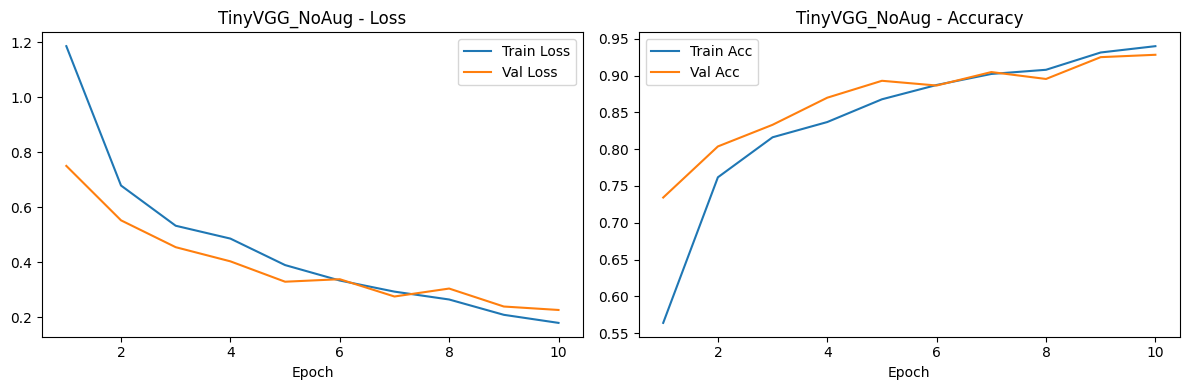

[TinyVGG_NoAug] Test Accuracy: 0.9190


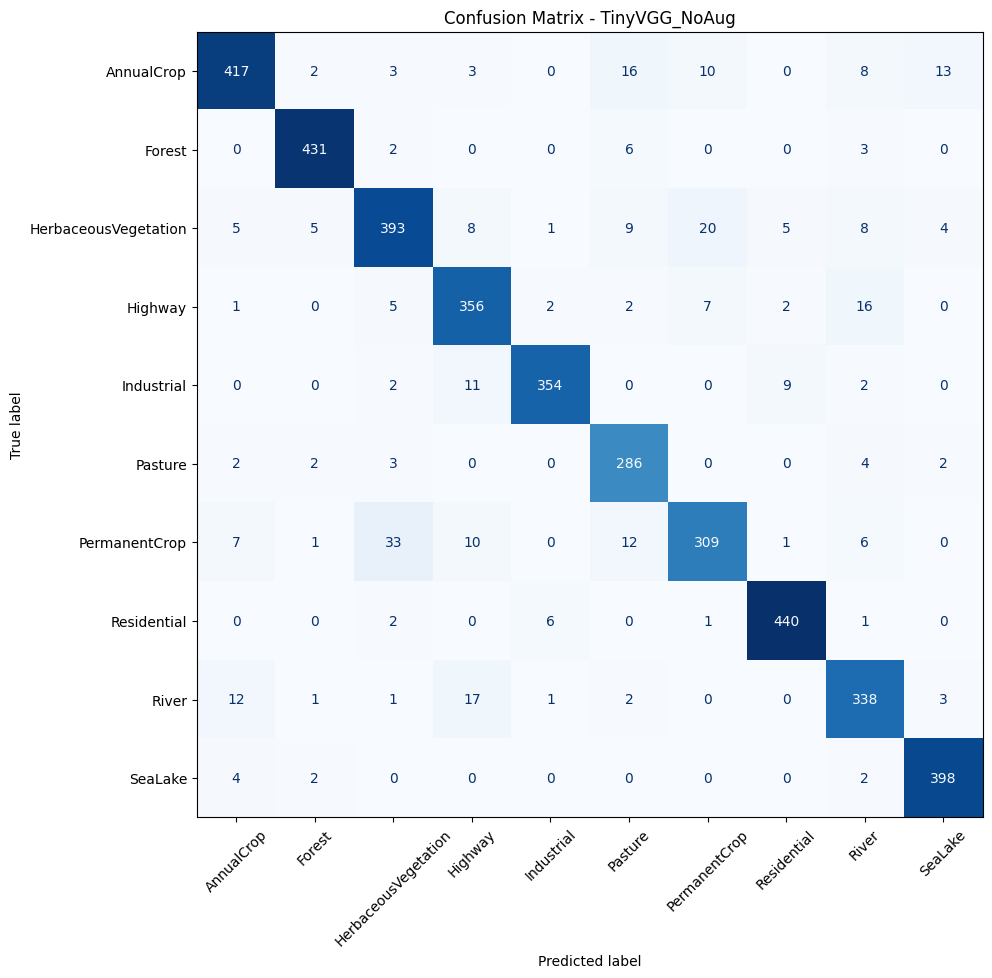

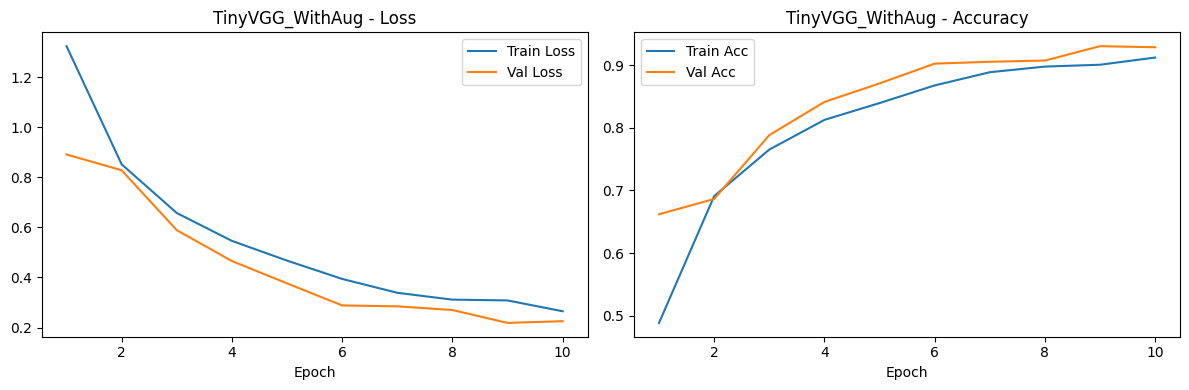

[TinyVGG_WithAug] Test Accuracy: 0.9207


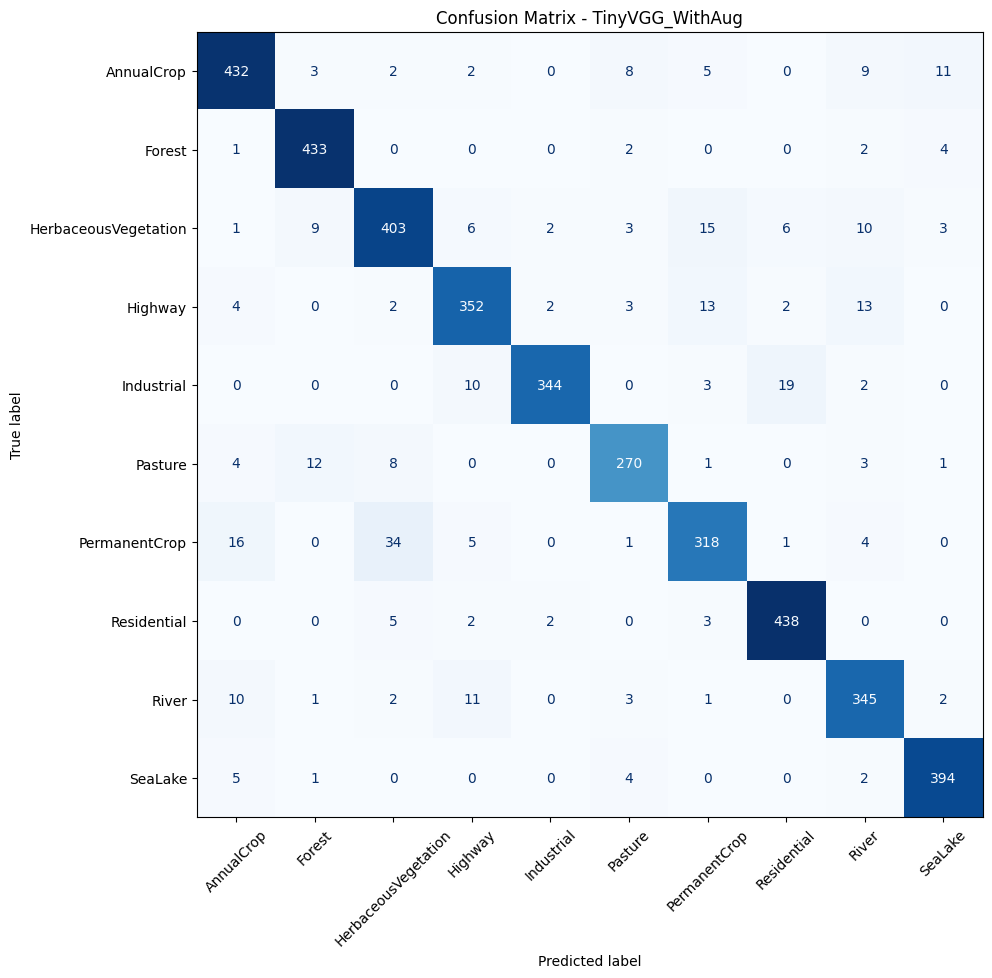

(0.9207407407407407,
 array([[432,   3,   2,   2,   0,   8,   5,   0,   9,  11],
        [  1, 433,   0,   0,   0,   2,   0,   0,   2,   4],
        [  1,   9, 403,   6,   2,   3,  15,   6,  10,   3],
        [  4,   0,   2, 352,   2,   3,  13,   2,  13,   0],
        [  0,   0,   0,  10, 344,   0,   3,  19,   2,   0],
        [  4,  12,   8,   0,   0, 270,   1,   0,   3,   1],
        [ 16,   0,  34,   5,   0,   1, 318,   1,   4,   0],
        [  0,   0,   5,   2,   2,   0,   3, 438,   0,   0],
        [ 10,   1,   2,  11,   0,   3,   1,   0, 345,   2],
        [  5,   1,   0,   0,   0,   4,   0,   0,   2, 394]]))

In [17]:
plot_curves(hist_scratch_plain, "TinyVGG_NoAug")
evaluate_model(model_scratch_plain, loaders_plain["test"], class_names, "TinyVGG_NoAug")

plot_curves(hist_scratch_aug, "TinyVGG_WithAug")
evaluate_model(model_scratch_aug, loaders_aug["test"], class_names, "TinyVGG_WithAug")

In [18]:
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights

def build_pretrained_model(num_classes=10):
    weights = MobileNet_V2_Weights.DEFAULT
    model = mobilenet_v2(weights=weights)

    # Freeze all feature-extraction layers
    for param in model.features.parameters():
        param.requires_grad = False

    # Replace the classifier head for our 10 classes
    model.classifier[1] = nn.Linear(model.last_channel, num_classes)

    return model

# Sanity check
test_pretrained = build_pretrained_model(10).to(device)
sample = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)
out = test_pretrained(sample)
print("Output shape:", out.shape)  # should be [1, 10]

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 64.8MB/s]


Output shape: torch.Size([1, 10])


In [19]:
model_pretrained_plain = build_pretrained_model(num_classes=10)
model_pretrained_plain, hist_pretrained_plain = train_model(
    model_pretrained_plain, loaders_plain, num_epochs=10, lr=0.001,
    model_name="MobileNetV2_NoAug"
)

[MobileNetV2_NoAug] Epoch 1/10 | Train Loss: 0.9031, Train Acc: 0.7630 | Val Loss: 0.5409, Val Acc: 0.8553
[MobileNetV2_NoAug] Epoch 2/10 | Train Loss: 0.5808, Train Acc: 0.8373 | Val Loss: 0.4666, Val Acc: 0.8649
[MobileNetV2_NoAug] Epoch 3/10 | Train Loss: 0.5224, Train Acc: 0.8466 | Val Loss: 0.4353, Val Acc: 0.8716
[MobileNetV2_NoAug] Epoch 4/10 | Train Loss: 0.5009, Train Acc: 0.8498 | Val Loss: 0.4170, Val Acc: 0.8741
[MobileNetV2_NoAug] Epoch 5/10 | Train Loss: 0.4849, Train Acc: 0.8487 | Val Loss: 0.4081, Val Acc: 0.8756
[MobileNetV2_NoAug] Epoch 6/10 | Train Loss: 0.4753, Train Acc: 0.8512 | Val Loss: 0.4091, Val Acc: 0.8775
[MobileNetV2_NoAug] Epoch 7/10 | Train Loss: 0.4563, Train Acc: 0.8576 | Val Loss: 0.4052, Val Acc: 0.8741
[MobileNetV2_NoAug] Epoch 8/10 | Train Loss: 0.4637, Train Acc: 0.8515 | Val Loss: 0.4008, Val Acc: 0.8788
[MobileNetV2_NoAug] Epoch 9/10 | Train Loss: 0.4509, Train Acc: 0.8584 | Val Loss: 0.3980, Val Acc: 0.8726
[MobileNetV2_NoAug] Epoch 10/10 | Tra

In [20]:
model_pretrained_aug = build_pretrained_model(num_classes=10)
model_pretrained_aug, hist_pretrained_aug = train_model(
    model_pretrained_aug, loaders_aug, num_epochs=10, lr=0.001,
    model_name="MobileNetV2_WithAug"
)

[MobileNetV2_WithAug] Epoch 1/10 | Train Loss: 0.9800, Train Acc: 0.7196 | Val Loss: 0.6240, Val Acc: 0.8378
[MobileNetV2_WithAug] Epoch 2/10 | Train Loss: 0.6712, Train Acc: 0.7936 | Val Loss: 0.5303, Val Acc: 0.8501
[MobileNetV2_WithAug] Epoch 3/10 | Train Loss: 0.6248, Train Acc: 0.8043 | Val Loss: 0.4970, Val Acc: 0.8585
[MobileNetV2_WithAug] Epoch 4/10 | Train Loss: 0.6094, Train Acc: 0.8075 | Val Loss: 0.4772, Val Acc: 0.8644
[MobileNetV2_WithAug] Epoch 5/10 | Train Loss: 0.5967, Train Acc: 0.8126 | Val Loss: 0.4766, Val Acc: 0.8595
[MobileNetV2_WithAug] Epoch 6/10 | Train Loss: 0.5936, Train Acc: 0.8112 | Val Loss: 0.4521, Val Acc: 0.8595
[MobileNetV2_WithAug] Epoch 7/10 | Train Loss: 0.5907, Train Acc: 0.8125 | Val Loss: 0.4666, Val Acc: 0.8637
[MobileNetV2_WithAug] Epoch 8/10 | Train Loss: 0.5951, Train Acc: 0.8101 | Val Loss: 0.4475, Val Acc: 0.8640
[MobileNetV2_WithAug] Epoch 9/10 | Train Loss: 0.5834, Train Acc: 0.8156 | Val Loss: 0.4538, Val Acc: 0.8647
[MobileNetV2_WithAu

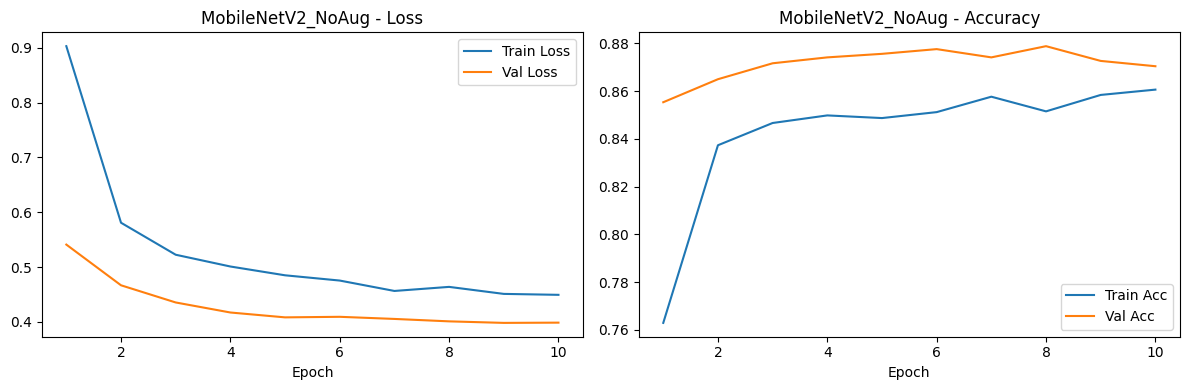

[MobileNetV2_NoAug] Test Accuracy: 0.8595


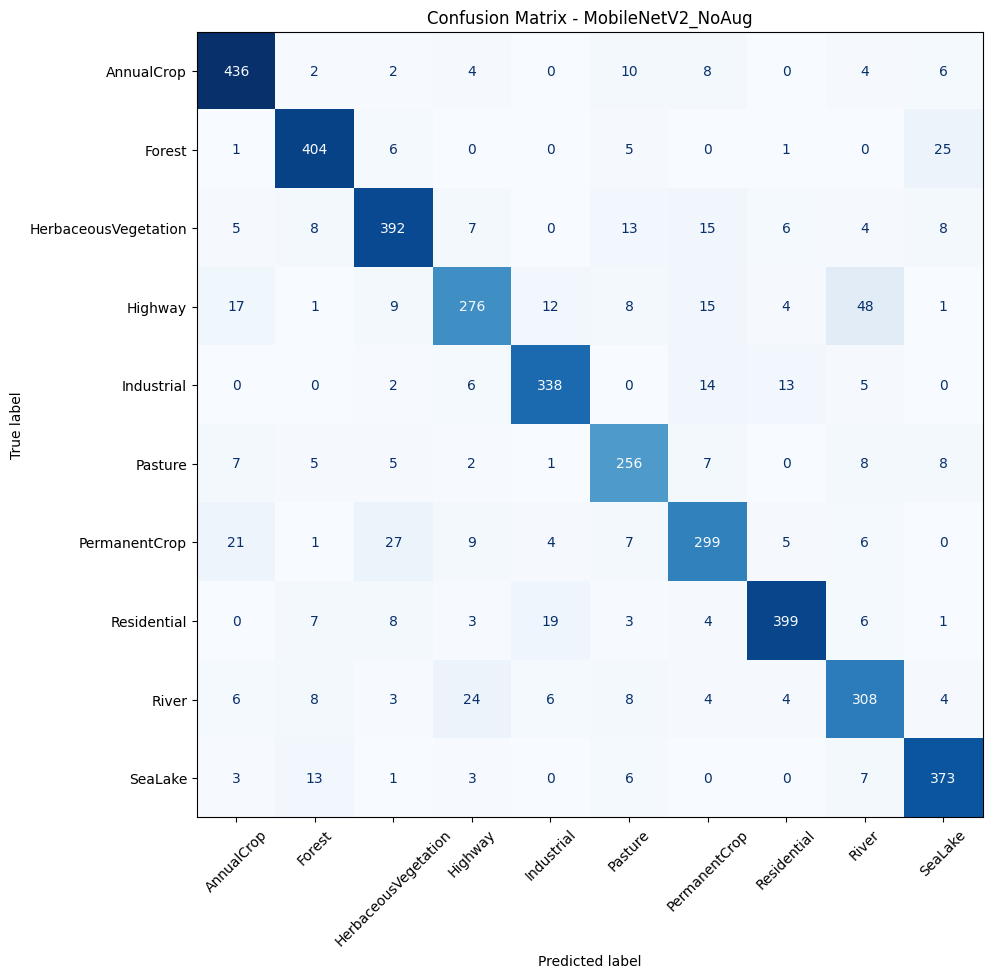

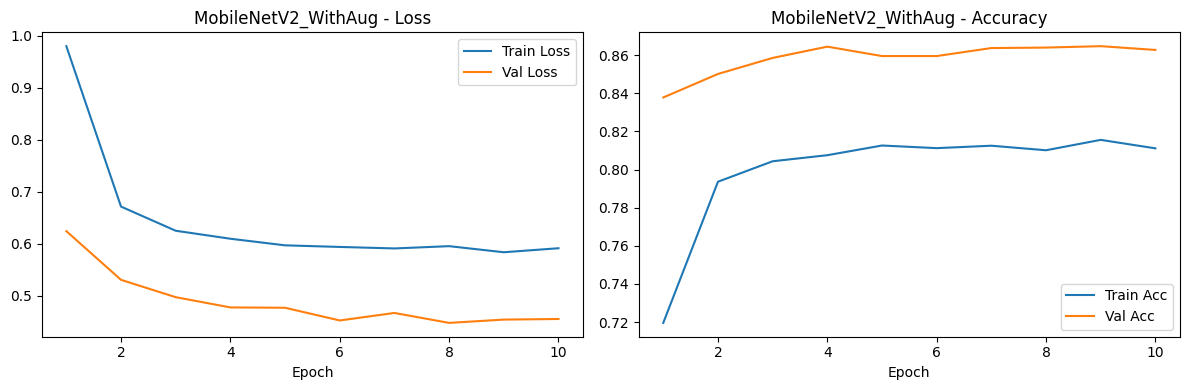

[MobileNetV2_WithAug] Test Accuracy: 0.8472


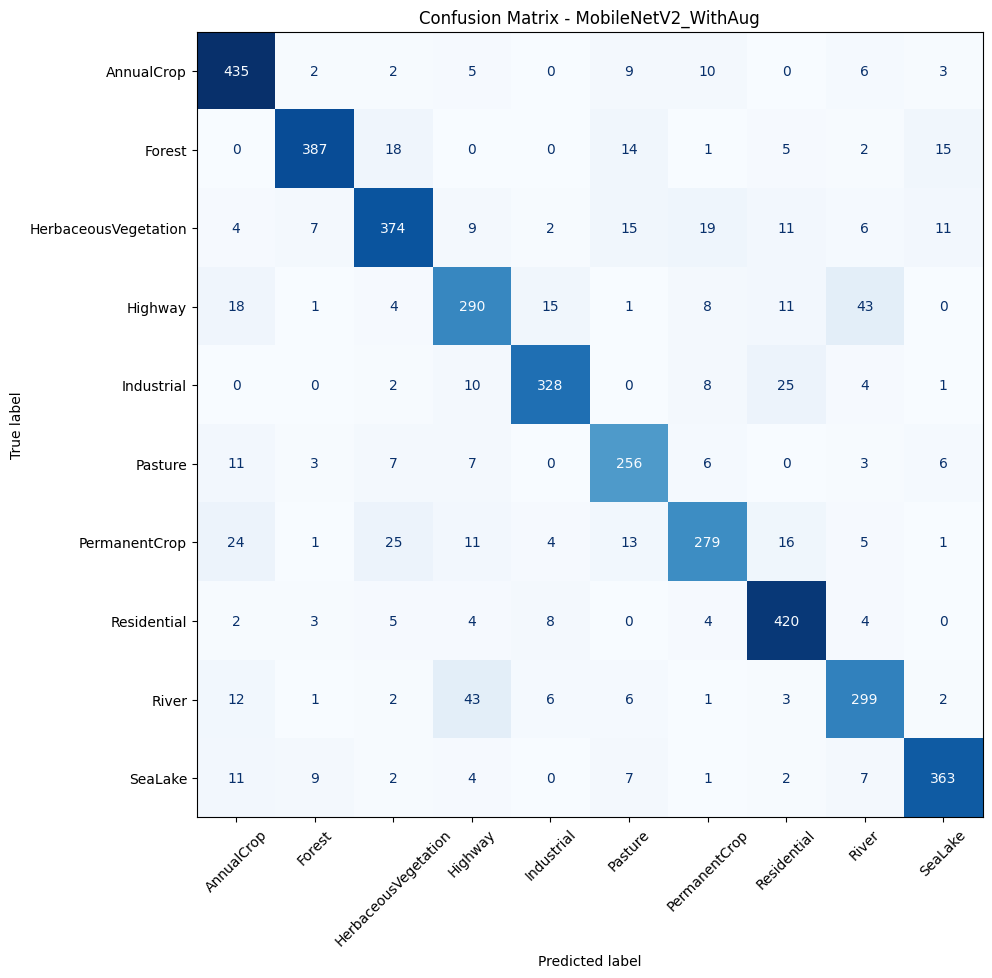

(0.8471604938271605,
 array([[435,   2,   2,   5,   0,   9,  10,   0,   6,   3],
        [  0, 387,  18,   0,   0,  14,   1,   5,   2,  15],
        [  4,   7, 374,   9,   2,  15,  19,  11,   6,  11],
        [ 18,   1,   4, 290,  15,   1,   8,  11,  43,   0],
        [  0,   0,   2,  10, 328,   0,   8,  25,   4,   1],
        [ 11,   3,   7,   7,   0, 256,   6,   0,   3,   6],
        [ 24,   1,  25,  11,   4,  13, 279,  16,   5,   1],
        [  2,   3,   5,   4,   8,   0,   4, 420,   4,   0],
        [ 12,   1,   2,  43,   6,   6,   1,   3, 299,   2],
        [ 11,   9,   2,   4,   0,   7,   1,   2,   7, 363]]))

In [21]:
plot_curves(hist_pretrained_plain, "MobileNetV2_NoAug")
evaluate_model(model_pretrained_plain, loaders_plain["test"], class_names, "MobileNetV2_NoAug")

plot_curves(hist_pretrained_aug, "MobileNetV2_WithAug")
evaluate_model(model_pretrained_aug, loaders_aug["test"], class_names, "MobileNetV2_WithAug")


In [22]:
import pandas as pd

results = {
    "Model": ["TinyVGG (scratch)", "TinyVGG (scratch)", "MobileNetV2 (fine-tuned)", "MobileNetV2 (fine-tuned)"],
    "Augmentation": ["No", "Yes", "No", "Yes"],
    "Test Accuracy": [0.9390, 0.9207, 0.8595, 0.8472]
}

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))
df_results.to_csv("results_summary.csv", index=False)

                   Model Augmentation  Test Accuracy
       TinyVGG (scratch)           No         0.9390
       TinyVGG (scratch)          Yes         0.9207
MobileNetV2 (fine-tuned)           No         0.8595
MobileNetV2 (fine-tuned)          Yes         0.8472
